In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

2 Physical GPUs, 2 Logical GPUs


In [4]:
batch_size = 32
img_height = 180
img_width = 180
channels = 3

In [5]:
## Write your train dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r'/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/',
    shuffle =True ,
    image_size =(img_height,img_width)  , # image_size =(180,180,3)
    batch_size = batch_size             # 32
)

Found 2239 files belonging to 9 classes.


In [6]:
train_ds.class_names

['actinic keratosis',
 'basal cell carcinoma',
 'dermatofibroma',
 'melanoma',
 'nevus',
 'pigmented benign keratosis',
 'seborrheic keratosis',
 'squamous cell carcinoma',
 'vascular lesion']

In [8]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r'/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test/',
    shuffle =True ,
    image_size =(img_height,img_width)  , # image_size = (180,180,3)
    batch_size = batch_size             # 32
)

Found 118 files belonging to 9 classes.


In [9]:
len(val_ds)

4

In [10]:
for image_batch , lable_batch in val_ds.take(1) :
    print('this is one batch shape :',image_batch.shape)  # (batch_size,img_height,img_width,chanells)  
    print('this is lable shape :',lable_batch.shape)

this is one batch shape : (32, 180, 180, 3)
this is lable shape : (32,)


In [11]:
for image_batch , label_batch in train_ds.take(1):
    print(image_batch.numpy())
    print('\n')
    print('convergt the lable in numeric : ',label_batch.numpy())

[[[[163.31815  140.31815  125.05148 ]
   [166.26334  147.26334  130.99667 ]
   [166.38147  149.9111   129.64629 ]
   ...
   [172.72217  154.72217  130.72217 ]
   [167.96667  150.96667  124.966675]
   [165.1818   147.44847  117.44846 ]]

  [[160.54445  137.54445  119.744446]
   [165.06999  142.33     124.399994]
   [168.55     147.85     126.80556 ]
   ...
   [169.7001   153.55566  127.700096]
   [169.39331  153.39331  127.39331 ]
   [167.9      150.9      120.9     ]]

  [[164.79816  141.79816  123.79815 ]
   [163.5      141.5      120.5     ]
   [168.4537   143.4537   123.453705]
   ...
   [172.67603  155.67603  127.676025]
   [171.96112  154.96112  124.96112 ]
   [168.28702  149.28702  117.28702 ]]

  ...

  [[181.3223   165.3223   150.3223  ]
   [176.3666   158.3666   144.3666  ]
   [177.27777  158.27777  143.27777 ]
   ...
   [182.2687   170.2687   156.82437 ]
   [179.11108  172.02777  156.13885 ]
   [179.5796   172.5796   156.36113 ]]

  [[175.99666  157.99666  146.19673 ]
   [174

In [12]:
class_names = train_ds.class_names
print(class_names)
n_classes = len(class_names)
print(n_classes)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
9


(32, 180, 180, 3)
[4 5 4 7 6 4 4 3 5 3 0 5 3 3 3 1 3 1 4 3 2 1 3 1 3 5 1 8 4 7 5 7]


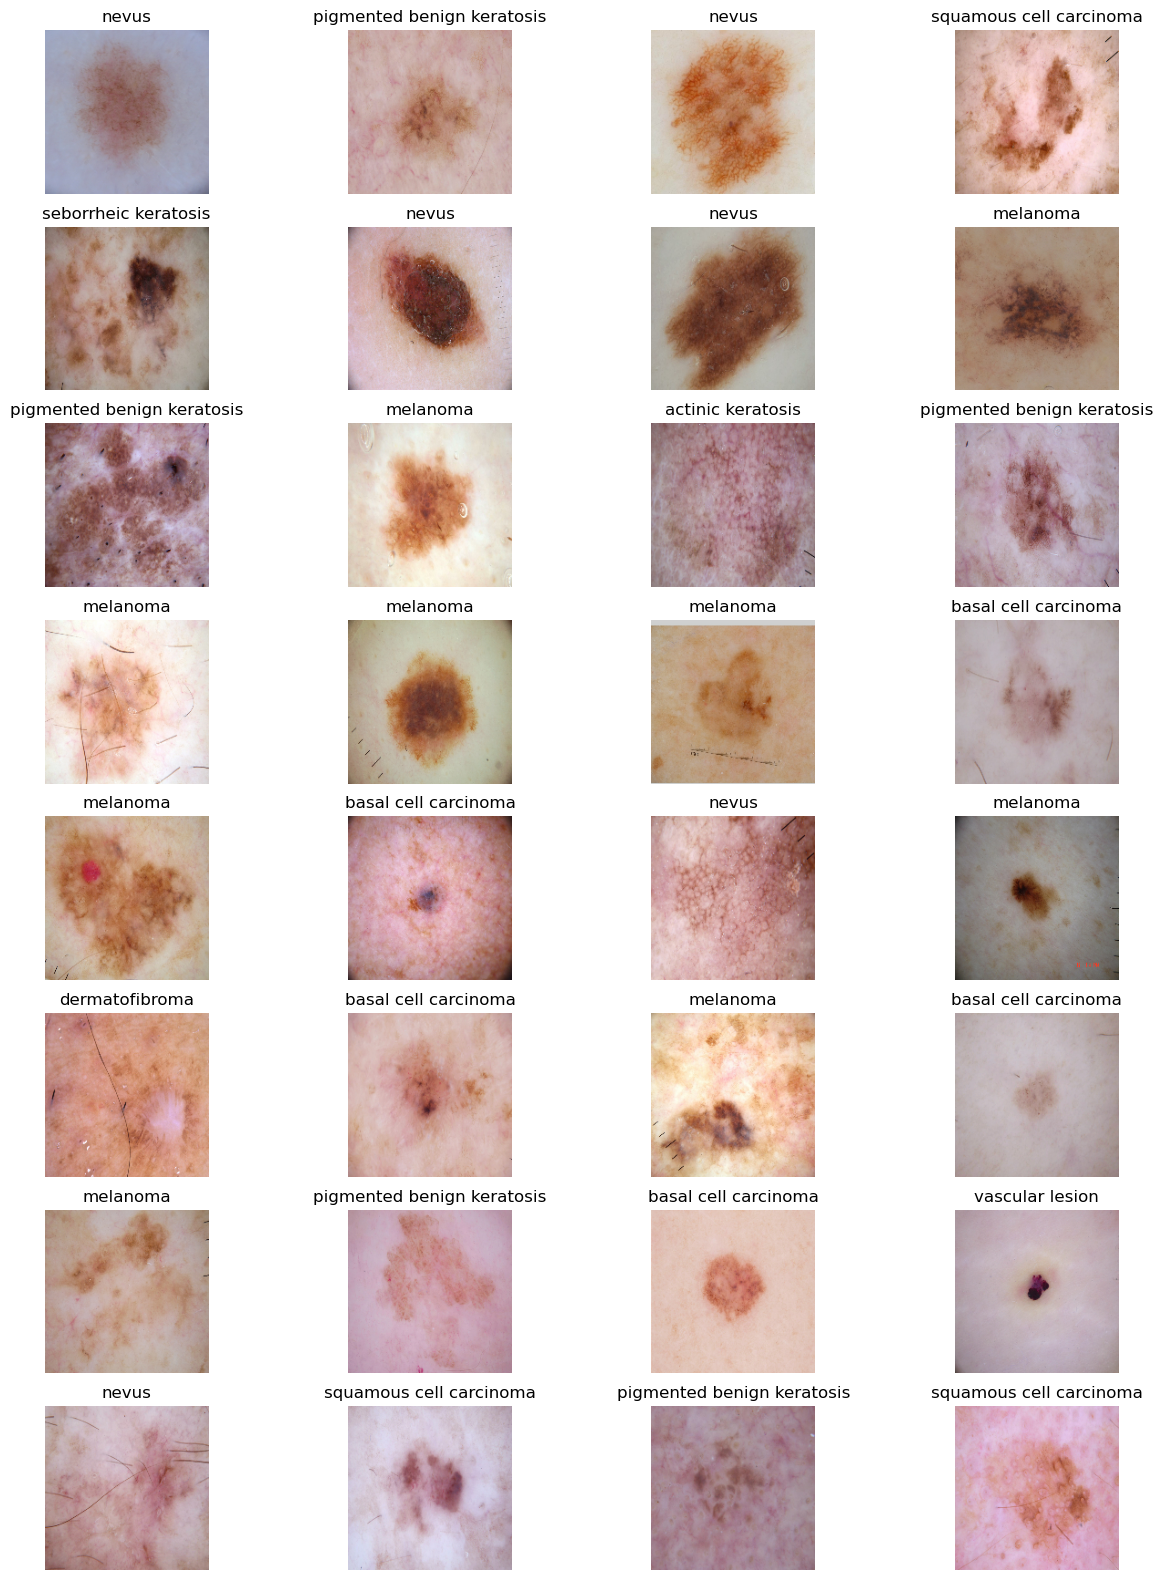

In [13]:
import matplotlib.pyplot as plt

### your code goes here, you can use training or validation data to visualize

plt.figure(figsize=(15,20))
for image_batch , labels_batch in train_ds.take(1):
  print(image_batch.shape)
  print(labels_batch.numpy())
  for i in range(32):
    plt.subplot(8,4,i+1)
    plt.imshow(image_batch[i].numpy().astype('uint8'))
    plt.title(class_names[labels_batch[i]])
    plt.axis('off')

In [14]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

In [15]:
# resize and rescale the value 
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.experimental.preprocessing.Resizing(img_height,img_width),
    tf.keras.layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [16]:
# data augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.experimental.preprocessing.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.experimental.preprocessing.RandomRotation(0.3)
])

In [17]:
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D ,BatchNormalization

In [18]:
input_shape = (batch_size , img_height , img_width , channels)

In [19]:
def create_model():
        # create CNN model

        model = Sequential()


        model.add(resize_and_rescale)

        model.add(data_augmentation)

        model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=input_shape))

        model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))

        model.add(MaxPooling2D(2,2))

        model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))

        model.add(MaxPooling2D(2,2))

        model.add(Flatten())

        model.add(Dense(32,activation='relu'))

        model.add(Dense(64,activation='relu'))

        model.add(Dropout(0.10))

        model.add(Dense(n_classes))

        return model

In [20]:
strategy = tf.distribute.MirroredStrategy()
print("Total GPUs : ", strategy.num_replicas_in_sync)

Total GPUs :  2


In [21]:
with strategy.scope() as scope:
    model = create_model()
    model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
    model.build(input_shape)
    model.summary()
    epochs = 5
    history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
    )

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 180, 180, 3)         0         
                                                                 
 sequential_1 (Sequential)   (32, 180, 180, 3)         0         
                                                                 
 conv2d (Conv2D)             (32, 180, 180, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (32, 180, 180, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2D  (32, 90, 90, 64)         0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (32, 90, 90, 64)          36928     
                                                      

In [23]:
# accuracy of model each epochs
history.history['accuracy']

[0.18579722940921783,
 0.21929432451725006,
 0.33318445086479187,
 0.39213934540748596,
 0.41670387983322144]

In [24]:
# validation accuracy of model each epochs
history.history['val_accuracy']

[0.1355932205915451,
 0.12711864709854126,
 0.20338982343673706,
 0.27966102957725525,
 0.29661017656326294]

In [25]:
# lost
history.history['loss']

[2.2229397296905518,
 1.99867582321167,
 1.8126564025878906,
 1.648921251296997,
 1.6262195110321045]

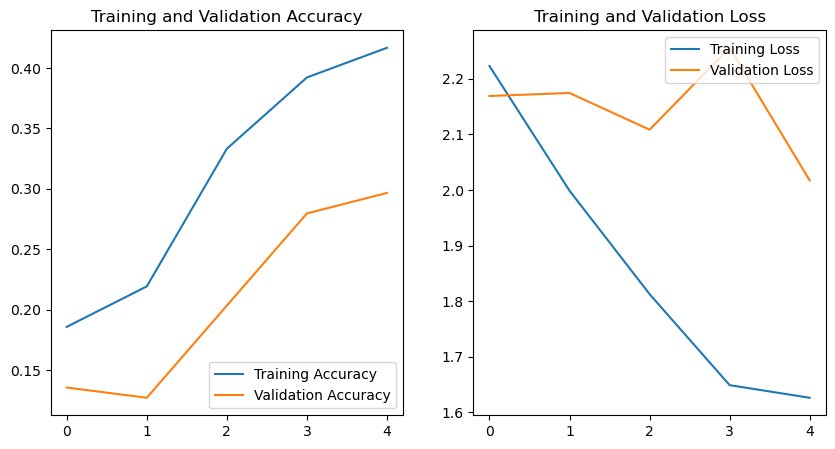

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [27]:
# Todo, after you have analysed the model fit history for presence of underfit or overfit, choose an appropriate data augumentation strategy. 
# Your code goes here

# data augmentation


data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1)
  ]
)

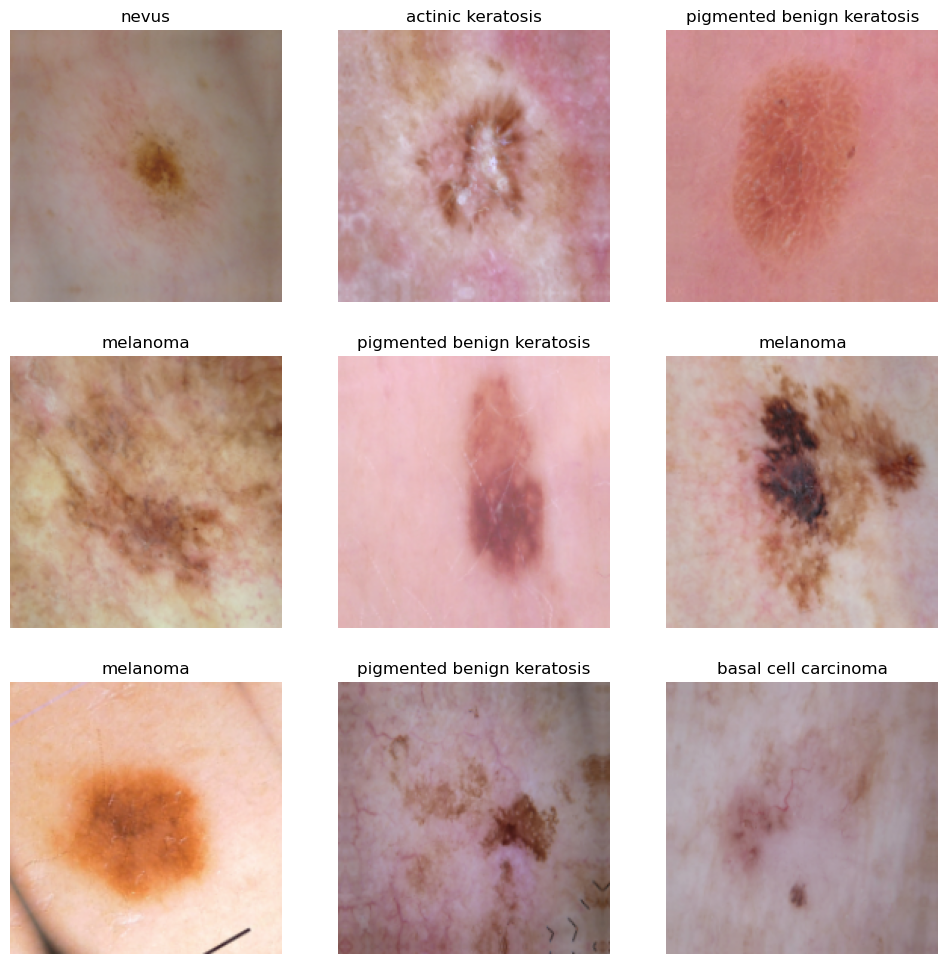

In [28]:
# Todo, visualize how your augmentation strategy works for one instance of training image.
# Your code goes here
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [29]:
def create_model():
    ## You can use Dropout layer if there is an evidence of overfitting in your findings

    ## Your code goes here

    model = Sequential()

    model.add(data_augmentation)

    model.add(resize_and_rescale)

    model.add(Conv2D(16,kernel_size=(3,3),padding='same',activation='relu'))

    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu'))

    model.add(MaxPooling2D(2,2))


    model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))


    model.add(MaxPooling2D(2,2))

    model.add(Dropout(0.2))


    model.add(Flatten())

    model.add(Dense(128,activation='relu'))

    model.add(Dense(n_classes))
    
    return model

In [30]:
with strategy.scope() as scope:
    model = create_model()
    model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
    model.build(input_shape)
    model.summary()
    epochs = 5
    history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
    )

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 sequential (Sequential)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 90, 90, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 45, 45, 32)       0         
 2D)                                                  

2023-07-24 08:12:50.700461: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_4/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


70/70 [==============================] - 9s 46ms/step - loss: 1.9505 - accuracy: 0.3059 - val_loss: 2.1889 - val_accuracy: 0.2034
Epoch 2/5
70/70 [==============================] - 3s 36ms/step - loss: 1.6028 - accuracy: 0.4355 - val_loss: 2.1166 - val_accuracy: 0.2966
Epoch 3/5
70/70 [==============================] - 2s 34ms/step - loss: 1.4630 - accuracy: 0.4886 - val_loss: 2.2174 - val_accuracy: 0.2966
Epoch 4/5
70/70 [==============================] - 2s 35ms/step - loss: 1.3924 - accuracy: 0.5163 - val_loss: 1.7866 - val_accuracy: 0.4237
Epoch 5/5
70/70 [==============================] - 2s 34ms/step - loss: 1.3599 - accuracy: 0.5141 - val_loss: 2.2762 - val_accuracy: 0.3644


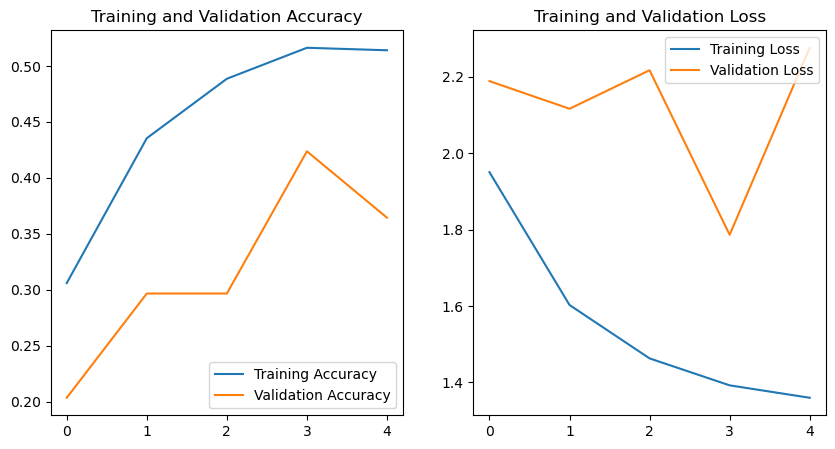

In [31]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [54]:
import shutil

source_directory = "/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/"
destination_directory = "/kaggle/working/melanoma-classes"

# Use shutil.copytree() to copy the entire directory and its contents
try:
    shutil.copytree(source_directory, destination_directory)
    print("Directory copied successfully.")
except OSError as e:
    print(f"Error: {e}")

Directory copied successfully.


In [62]:
data_dir_train = pathlib.Path(r"/kaggle/working/melanoma-classes/Train")

In [63]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)

2239


In [64]:
#plot number of images in each Class
count=[]
for name in class_names:
    count.append(len(list(data_dir_train.glob(name+'/*.jpg'))))

In [65]:
count

[114, 376, 95, 438, 357, 462, 77, 181, 139]

<BarContainer object of 9 artists>

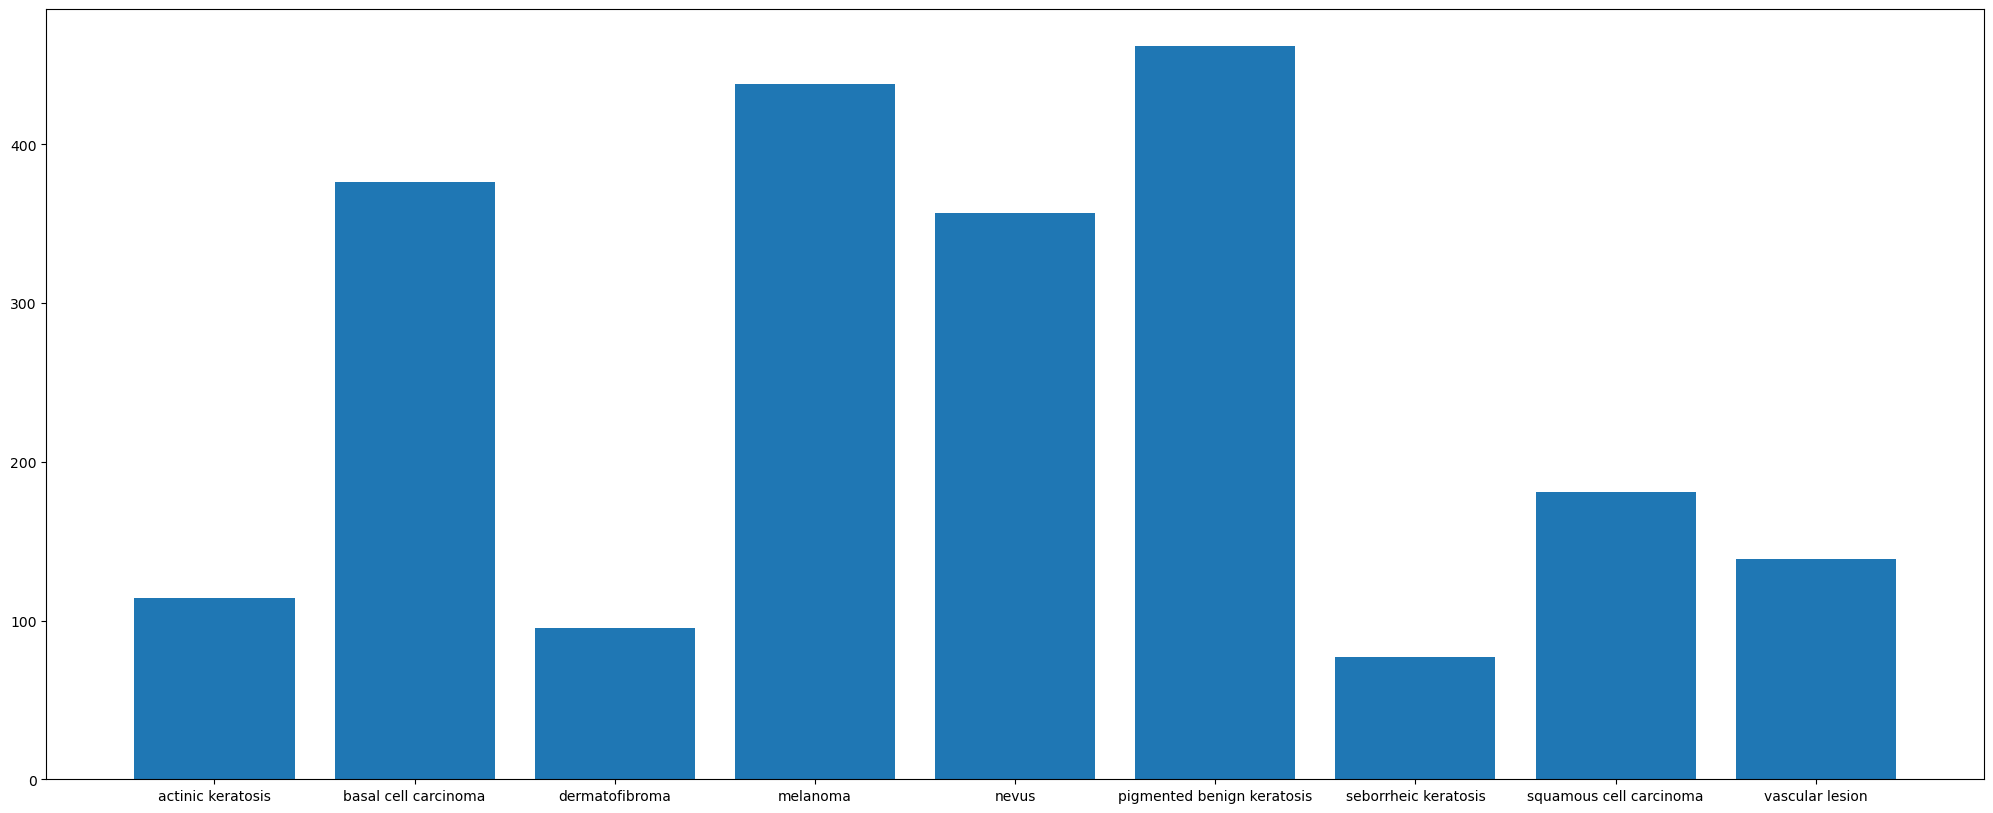

In [66]:
#plot number of images in each Class
count=[]
for name in class_names:
    count.append(len(list(data_dir_train.glob(name+'/*.jpg'))))
plt.figure(figsize=(25,10))
plt.bar(class_names,count)

In [47]:
!pip install Augmentor

In [67]:
path_to_training_dataset=str(data_dir_train)+'/'
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500) ## We are adding 500 samples per class to make sure that none of the classes are sparse.

Initialised with 114 image(s) found.
Output directory set to /kaggle/working/melanoma-classes/Train/actinic keratosis/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7FE13501F8B0>: 100%|██████████| 500/500 [00:12<00:00, 39.44 Samples/s]


Initialised with 376 image(s) found.
Output directory set to /kaggle/working/melanoma-classes/Train/basal cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7FE135237B80>: 100%|██████████| 500/500 [00:12<00:00, 39.10 Samples/s]                  


Initialised with 95 image(s) found.
Output directory set to /kaggle/working/melanoma-classes/Train/dermatofibroma/output.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7FE1353F7670>: 100%|██████████| 500/500 [00:32<00:00, 15.50 Samples/s]                  


Initialised with 181 image(s) found.
Output directory set to /kaggle/working/melanoma-classes/Train/squamous cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7FE13555BC10>: 100%|██████████| 500/500 [00:12<00:00, 39.13 Samples/s]                  


Initialised with 139 image(s) found.
Output directory set to /kaggle/working/melanoma-classes/Train/vascular lesion/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7FE13516CB80>: 100%|██████████| 500/500 [00:12<00:00, 39.73 Samples/s]


In [68]:
#Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types.. 
#Lets take a look at total count of augmented images.

image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

4500


<BarContainer object of 9 artists>

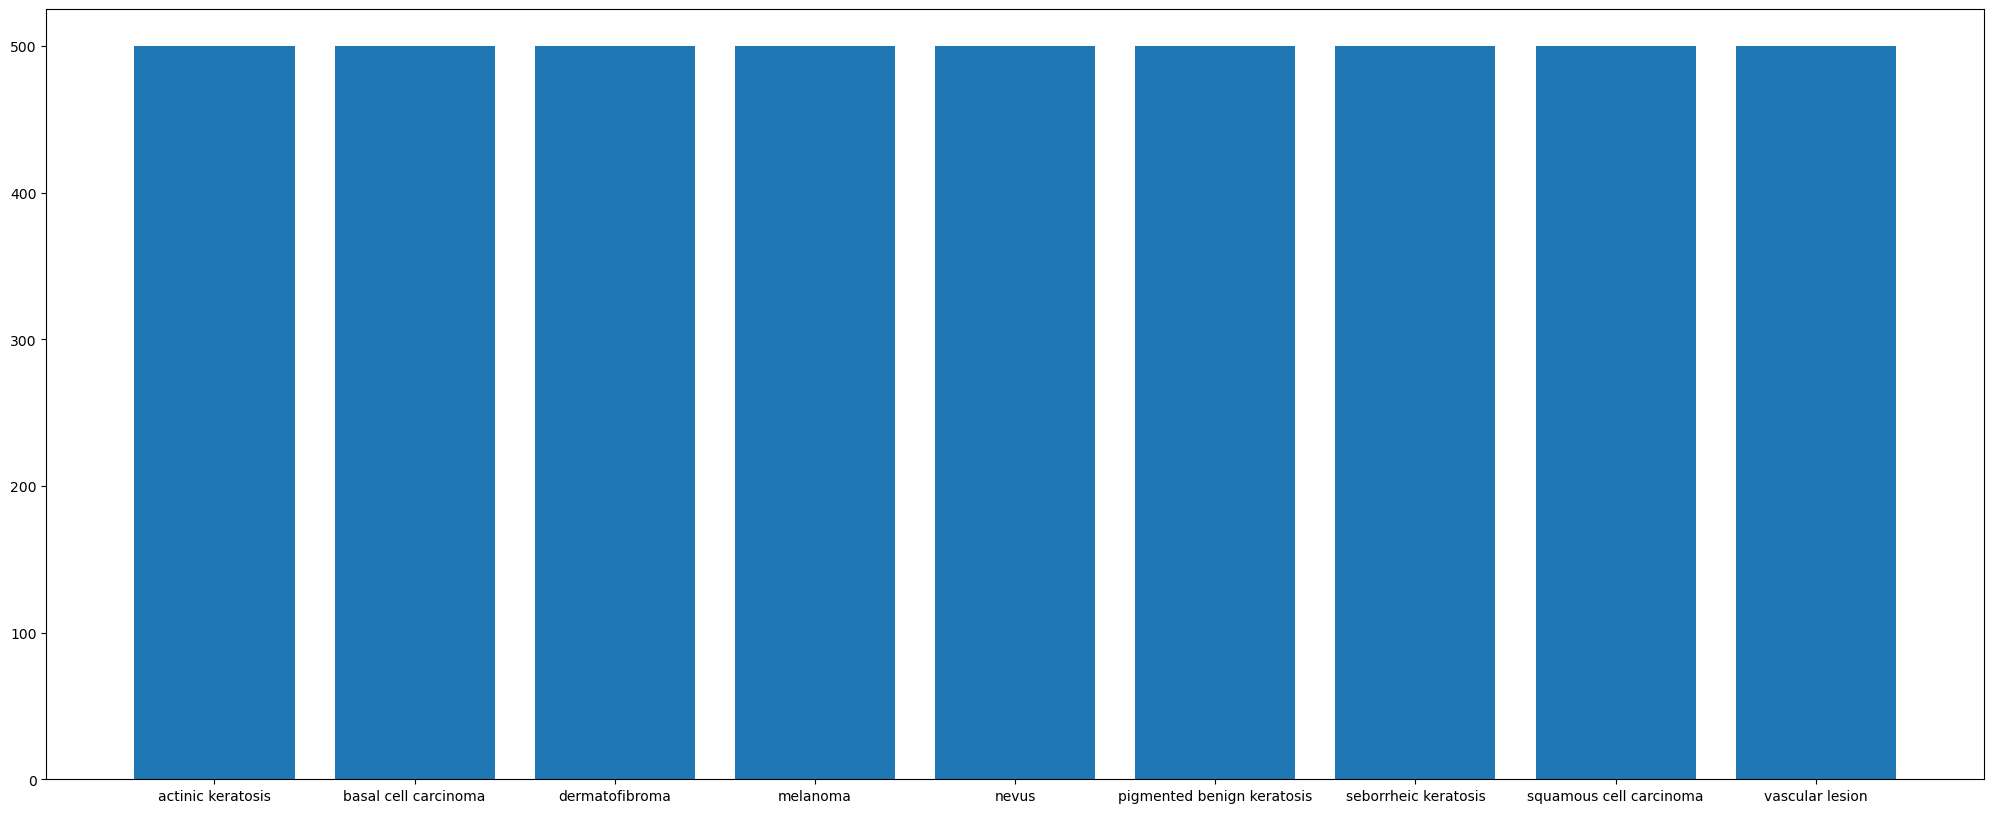

In [69]:
# Check the distribution of data again. 
count=[]
for name in class_names:
    count.append(len(list(data_dir_train.glob(name+'*/output/*.jpg'))))
plt.figure(figsize=(25,10))
plt.bar(class_names,count)

In [70]:
import os
from glob import glob

In [71]:
path_list_new = [x for x in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
path_list_new

['/kaggle/working/melanoma-classes/Train/actinic keratosis/output/actinic keratosis_original_ISIC_0028370.jpg_57998791-b1ad-4983-b444-a524f40326c1.jpg',
 '/kaggle/working/melanoma-classes/Train/actinic keratosis/output/actinic keratosis_original_ISIC_0028517.jpg_06049866-e56b-4c43-8d5d-0d2a64758523.jpg',
 '/kaggle/working/melanoma-classes/Train/actinic keratosis/output/actinic keratosis_original_ISIC_0026765.jpg_47814b7c-bfff-4c8c-8d28-35beaa207087.jpg',
 '/kaggle/working/melanoma-classes/Train/actinic keratosis/output/actinic keratosis_original_ISIC_0026575.jpg_b2df9510-7438-4511-8012-12652a4074dd.jpg',
 '/kaggle/working/melanoma-classes/Train/actinic keratosis/output/actinic keratosis_original_ISIC_0026702.jpg_e9f4e12a-a029-4971-b974-b33bfb676439.jpg',
 '/kaggle/working/melanoma-classes/Train/actinic keratosis/output/actinic keratosis_original_ISIC_0029781.jpg_ae098d84-7813-4bdf-b4c8-38b3906ea389.jpg',
 '/kaggle/working/melanoma-classes/Train/actinic keratosis/output/actinic keratosi

In [72]:
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
lesion_list_new

['actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic 

In [73]:
dataframe_dict_new = dict(zip(path_list_new, lesion_list_new))

In [74]:
# Get Existing images in Dataframe
path_list=[]
lesion_list=[]
for name in class_names:
  for file in data_dir_train.glob(name+'/*.jpg'):
    path_list.append(str(file))
    lesion_list.append(name)

dataframe_dict_original=dict(zip(path_list,lesion_list))
original_df=pd.DataFrame(list(dataframe_dict_original.items()),columns=['Path','Label'])

In [75]:
df2 = pd.DataFrame(list(dataframe_dict_new.items()),columns = ['Path','Label'])
new_df = original_df.append(df2)

/tmp/ipykernel_29/390629722.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_df = original_df.append(df2)


In [76]:
new_df['Label'].value_counts()

pigmented benign keratosis    962
melanoma                      938
basal cell carcinoma          876
nevus                         857
squamous cell carcinoma       681
vascular lesion               639
actinic keratosis             614
dermatofibroma                595
seborrheic keratosis          577
Name: Label, dtype: int64

In [77]:
batch_size = 32
img_height = 180
img_width = 180

In [78]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  validation_split = 0.2,
  subset = 'training',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


In [79]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  validation_split = 0.2,
  subset = 'validation',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


In [80]:
## your code goes here
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [81]:
def create_model():
    model = Sequential([
      layers.experimental.preprocessing.Rescaling(1./255),
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Dropout(0.2),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(n_classes)
    ])
    return model

In [86]:
with strategy.scope() as scope:
    model = create_model()
    ## your code goes here
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    model.build(input_shape)
    model.summary()
    epochs = 20

    history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
    )

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (32, 180, 180, 3)         0         
                                                                 
 conv2d_12 (Conv2D)          (32, 180, 180, 16)        448       
                                                                 
 max_pooling2d_11 (MaxPoolin  (32, 90, 90, 16)         0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (32, 90, 90, 32)          4640      
                                                                 
 max_pooling2d_12 (MaxPoolin  (32, 45, 45, 32)         0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (32, 45, 45, 64)         

2023-07-24 08:38:35.501544: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_7/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


169/169 [==============================] - 9s 32ms/step - loss: 1.9305 - accuracy: 0.2736 - val_loss: 1.5457 - val_accuracy: 0.4336
Epoch 2/20
169/169 [==============================] - 5s 30ms/step - loss: 1.3874 - accuracy: 0.4898 - val_loss: 1.3758 - val_accuracy: 0.4989
Epoch 3/20
169/169 [==============================] - 5s 29ms/step - loss: 1.1578 - accuracy: 0.5812 - val_loss: 1.1323 - val_accuracy: 0.5739
Epoch 4/20
169/169 [==============================] - 5s 30ms/step - loss: 0.9615 - accuracy: 0.6528 - val_loss: 1.0450 - val_accuracy: 0.6147
Epoch 5/20
169/169 [==============================] - 5s 30ms/step - loss: 0.7838 - accuracy: 0.7201 - val_loss: 0.9848 - val_accuracy: 0.6667
Epoch 6/20
169/169 [==============================] - 5s 30ms/step - loss: 0.6104 - accuracy: 0.7795 - val_loss: 0.8061 - val_accuracy: 0.7268
Epoch 7/20
169/169 [==============================] - 5s 30ms/step - loss: 0.4698 - accuracy: 0.8288 - val_loss: 0.7901 - val_accuracy: 0.7409
Epoch 8/20

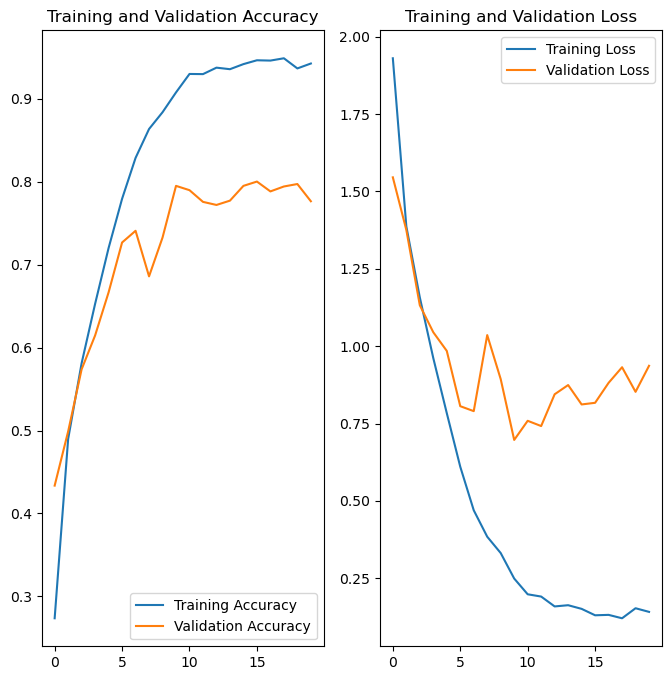

In [87]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [88]:
model.save("/kaggle/working/Melanoma_Detection.h5")